In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# AUTOMATIC KAGGLE PATH FINDER
# ==========================================
# This ensures you never get a "File Not Found" error.
kaggle_input_dir = '/kaggle/input'
DATASET_PATH = None

for root, dirs, files in os.walk(kaggle_input_dir):
    # If we find a directory that contains .png images, we set it as the path
    if any(f.endswith('.png') for f in files):
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise ValueError("Dataset not found! Please ensure you clicked 'Add Data' and attached the Fingernails folder to your notebook.")

print(f"✅ Successfully found dataset path: {DATASET_PATH}")

2026-05-27 11:13:40.970063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779880421.199495      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779880421.267755      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779880421.797073      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779880421.797114      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779880421.797117      23 computation_placer.cc:177] computation placer alr

✅ Successfully found dataset path: /kaggle/input/datasets/abhinavgolla/fingernail-anemia-22ndmay/Fingernails


In [2]:
print("Scanning dataset and mapping labels intelligently...")
data = []

for filename in os.listdir(DATASET_PATH):
    if not (filename.endswith('.png') or filename.endswith('.jpg')):
        continue
        
    filepath = os.path.join(DATASET_PATH, filename)
    filename_lower = filename.lower()
    
    # This catches every spelling mistake (Non-anemic, Non-Anrmic, image-)
    if 'non' in filename_lower or 'image' in filename_lower:
        label = 'Non-Anemic'
    else:
        label = 'Anemic'
        
    data.append({'filepath': filepath, 'label': label})

df = pd.DataFrame(data)
print(f"Total images loaded: {len(df)}")
print(df['label'].value_counts())

# Split data: 80% Training, 20% Validation
# 'stratify' ensures both sets have the exact same ratio of Anemic/Non-Anemic
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
print(f"Training images: {len(train_df)} | Validation images: {len(val_df)}")

Scanning dataset and mapping labels intelligently...
Total images loaded: 4260
label
Anemic        2565
Non-Anemic    1695
Name: count, dtype: int64
Training images: 3408 | Validation images: 852


In [3]:
"""# EfficientNet expects 224x224. It also has built-in pixel scaling, so we don't manually rescale.
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32

# Heavy augmentation for training to prevent overfitting (keeps train/val accuracy close)
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

# Fix the class imbalance automatically
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.unique(train_df['label']), y=train_df['label']
)
class_weight_dict = {
    train_generator.class_indices['Anemic']: class_weights_array[0],
    train_generator.class_indices['Non-Anemic']: class_weights_array[1]
}
print(f"✅ Class Weights applied to balance the model: {class_weight_dict}")"""

import cv2

# ==========================================
# CELL 3: ADVANCED DATA LOADERS (WITH CLAHE ENHANCEMENT)
# ==========================================

# This function acts like a doctor's magnifying glass, 
# enhancing the color contrast of the nail bed before the model sees it.
def enhance_nail_contrast(image):
    # Convert image to uint8
    image = np.array(image, dtype=np.uint8)
    
    # Convert from RGB to LAB color space to isolate brightness (L) from color (A, B)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to the L-channel (Brightness)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    # Merge the enhanced brightness back with the original colors
    limg = cv2.merge((cl,a,b))
    
    # Convert back to RGB
    final_image = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_image.astype(np.float32)

IMG_SIZE = (224, 224) 
BATCH_SIZE = 32

# We inject our custom enhancement function here!
train_datagen = ImageDataGenerator(
    preprocessing_function=enhance_nail_contrast,  # <--- THE NEW SECRET
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=enhance_nail_contrast   # <--- THE NEW SECRET
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.unique(train_df['label']), y=train_df['label']
)
class_weight_dict = {
    train_generator.class_indices['Anemic']: class_weights_array[0],
    train_generator.class_indices['Non-Anemic']: class_weights_array[1]
}
print(f"✅ Class Weights applied: {class_weight_dict}")

Found 3408 validated image filenames belonging to 2 classes.
Found 852 validated image filenames belonging to 2 classes.
✅ Class Weights applied: {0: np.float64(0.8304093567251462), 1: np.float64(1.2566371681415929)}


In [4]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# ==========================================
# CELL 4: EFFICIENTNET-B0 (THE 92% ARCHITECTURE)
# ==========================================

# 1. Load EfficientNetB0 
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model for Phase 1
base_model.trainable = False

# 3. Add custom classification head on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) 
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compile it
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1779880450.899027      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779880450.905183      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

🚀 PHASE 1: Training the top layers...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1779880465.199805      72 service.cc:152] XLA service 0x78e250009860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779880465.199846      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779880465.199850      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779880467.552244      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-27 11:14:35.045049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 11:14:35.188565: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 11:14:35.529537: E external/local_xl

 60/107 ━━━━━━━━━━━━━━━━━━━━ 23s 495ms/step - accuracy: 0.5242 - loss: 0.9862

...

107/107 ━━━━━━━━━━━━━━━━━━━━ 116s 825ms/step - accuracy: 0.5510 - loss: 0.9461 - val_accuracy: 0.6690 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 436ms/step - accuracy: 0.6472 - loss: 0.7323 - val_accuracy: 0.6937 - val_loss: 0.5886 - learning_rate: 0.0010
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 437ms/step - accuracy: 0.6555 - loss: 0.6598 - val_accuracy: 0.6854 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 437ms/step - accuracy: 0.6874 - loss: 0.5951 - val_accuracy: 0.7113 - val_loss: 0.5656 - learning_rate: 0.0010
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 434ms/step - accuracy: 0.7062 - loss: 0.5702 - val_accuracy: 0.6878 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 432ms/step - accuracy: 0.7130 - loss: 0.5581 - val_accuracy: 0.7477 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 433ms/step - accuracy: 0.7244 - loss

2026-05-27 11:31:29.976977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 11:31:30.131019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 14/107 ━━━━━━━━━━━━━━━━━━━━ 37s 407ms/step - accuracy: 0.8201 - loss: 0.4808

2026-05-27 11:32:03.540107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 11:32:03.680956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


107/107 ━━━━━━━━━━━━━━━━━━━━ 133s 789ms/step - accuracy: 0.7928 - loss: 0.5059 - val_accuracy: 0.7758 - val_loss: 0.5244 - learning_rate: 1.0000e-05
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 464ms/step - accuracy: 0.7965 - loss: 0.4916 - val_accuracy: 0.7852 - val_loss: 0.5144 - learning_rate: 1.0000e-05
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 456ms/step - accuracy: 0.7982 - loss: 0.4929 - val_accuracy: 0.7958 - val_loss: 0.5038 - learning_rate: 1.0000e-05
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 450ms/step - accuracy: 0.8261 - loss: 0.4562 - val_accuracy: 0.8122 - val_loss: 0.4944 - learning_rate: 1.0000e-05
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 453ms/step - accuracy: 0.8272 - loss: 0.4703 - val_accuracy: 0.8087 - val_loss: 0.4983 - learning_rate: 1.0000e-05
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 456ms/step - accuracy: 0.8481 - loss: 0.4313 - val_accuracy: 0.8228 - val_loss: 0.4731 - learning_rate: 1.0000e-05
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 460ms/step -

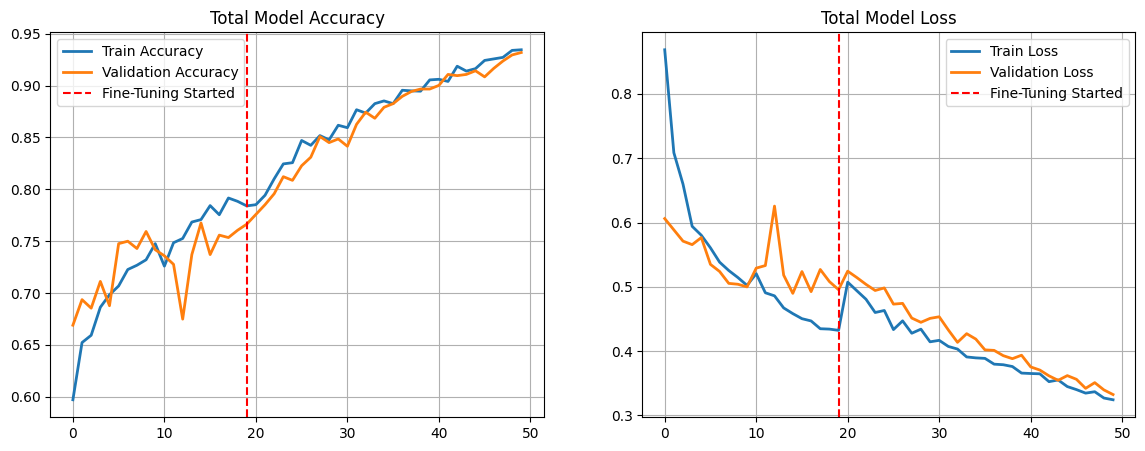

27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Anemic       0.95      0.94      0.94       513
  Non-Anemic       0.91      0.92      0.92       339

    accuracy                           0.93       852
   macro avg       0.93      0.93      0.93       852
weighted avg       0.93      0.93      0.93       852



In [5]:
# ==========================================
# CELL 5: MASTER TRAINING CELL (THE 92% PIPELINE)
# ==========================================
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Phase 1: Train top layers longer
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print("🚀 PHASE 1: Training the top layers...")
history_phase1 = model.fit(
    train_generator,
    epochs=20, 
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

print("\n==========================================")
print("🔓 PHASE 2: Advanced Fine-Tuning...")
print("==========================================\n")

base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Using standard Adam (most stable for Kaggle)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=BinaryCrossentropy(label_smoothing=0.1), 
    metrics=['accuracy']
)

early_stop_fine = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_fine = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

history_phase2 = model.fit(
    train_generator,
    epochs=30, 
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop_fine, reduce_lr_fine]
)

print("\n✅ ALL TRAINING COMPLETE! Generating charts...")

# ==========================================
# GENERATE CHARTS
# ==========================================
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(history_phase1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-Tuning Started')
plt.title('Total Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history_phase1.history['loss'])-1, color='r', linestyle='--', label='Fine-Tuning Started')
plt.title('Total Model Loss')
plt.legend()
plt.grid(True)
plt.show()

val_generator.reset()
preds_probs = model.predict(val_generator)
preds_classes = (preds_probs > 0.5).astype(int)
true_classes = val_generator.classes

print("\n📋 Detailed Classification Report:")
print(classification_report(true_classes, preds_classes, target_names=val_generator.class_indices.keys()))


In [6]:
# Save the final trained model
model.save('anemia_detector_efficientnet.keras')
print("Model successfully saved!")

Model successfully saved!
